# Epidemic Spreading in Hyperbolic Space (ES-HS)
TFG Adrià Rojo, 2026

## Compilar eines

In [7]:
! mkdir tools -p

### SD Model

In [1]:
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD

### Mercator

In [2]:
! g++ -O3 -std=c++11 -fpermissive -I ./mercator/include/ ./mercator/src/embeddingS1_unix.cpp -o ./tools/mercator


En el fichero incluido desde ./mercator/src/../include/Eigen/Core:467,
                 desde ./mercator/src/../include/embeddingS1.hpp:52,
                 desde ./mercator/src/../include/embeddingS1_unix.hpp:36,
                 desde ./mercator/src/embeddingS1_unix.cpp:30:
./mercator/src/../include/Eigen/src/Core/Transpositions.h: In function ‘const Eigen::Product<OtherDerived, Eigen::Transpose<Eigen::TranspositionsBase<Derived> >, 2> Eigen::operator*(const MatrixBase<OtherDerived>&, const Transpose<TranspositionsBase<Derived> >&)’:
./mercator/src/../include/Eigen/src/Core/Transpositions.h:387:87: aviso: ‘const class Eigen::Transpose<Eigen::TranspositionsBase<Derived> >’ has no member named ‘derived’ []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/C_002b_002b-Dialect-Options.html#index-Wno-template-body-Wtemplate-body]8;;]
  387 | Derived, Transpose, AliasFreeProduct>(matrix.derived(), trt.derived());
      |                                                             ^~~~~~~

### Epidemics

In [18]:
! gfortran -O3 -march=native -funroll-loops -fopenmp -g \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics
! gfortran -O3 -march=native -funroll-loops -g \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics_debug
! rm ./*.mod

In [ ]:
! ./tools/epidemics -h

## Generació de xarxes

In [ ]:
! ./tools/genSD -h

In [ ]:
! ./tools/mercator -h

In [3]:
! ./tools/genSD -d 1 -n 10000 -g 1.729 -k 11.53 -b 3 -s 12345 -o pipeline-output-s1h2/n10000

OUTPUT_ROOTNAME = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000
edgelist_file = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000.edge


In [1]:
! ./tools/mercator -o pipeline-output-s1h2/n10000 -b 3 -s 12345 ./pipeline-output-s1h2/n10000.edge

In [ ]:
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports.edges
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports_GC.edge


More than one component found (3304/3330) vertices in the largest component.
Edges belonging to the largest component saved to ./airports_GC.edge. Please rerun the program using this new edgelist.

terminate called without an active exception


## Visualització

### Funcions

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# Configuración estilo revtex4
plt.style.use('default')  # Empezar desde cero

rcparams = {
    # Fuentes
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size': 10,
    'font.weight': 'normal',
    
    # Tamaño de figura (ancho de columna típico de revtex4: ~3.5 pulgadas)
    'figure.figsize': (3.5, 2.8),
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    
    # Ejes
    'axes.labelsize': 10,
    'axes.labelweight': 'normal',
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'black',
    'axes.facecolor': 'white',
    
    # Ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    
    # Líneas
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    
    # Leyenda
    'legend.fontsize': 9,
    'legend.frameon': False,
    'legend.loc': 'best',
    
    # Guardado
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,

    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}',
    'pgf.texsystem': 'xelatex'
}

plt.rcParams.update(rcparams)

In [2]:
# arxiv 1v41801.4091
import gc
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg


def kappa_to_hyperbolic(kappa, kappa_min): # ln k/k_0
    """
    Convierte κ a coordenada radial hiperbólica
    r = ln(κ/κ_min)
    """
    return np.log(kappa / kappa_min)

def hyperbolic_to_mercator(r_hiperbolico, edge_count, mu, kappa_min):
    """
    Convierte radio hiperbólico a coordenada en disco de Poincaré
    r_poincare = R*-2*r_hyp
    """
    R = 2 * np.log(edge_count/(mu*np.pi*kappa_min**2))
    return R - 2* r_hiperbolico

kappa_to_hyperbolic = np.vectorize(kappa_to_hyperbolic, excluded={1, 'kappa_min'})
hyperbolic_to_mercator = np.vectorize(hyperbolic_to_mercator, excluded={1, 'edge_count', 2, 'mu', 3, 'kappa_min'})

def mercator_to_poincare(r_mercator, R):
    """
    Convierte coordenada radial en proyección Mercator a radio en disco de Poincaré.
    """
    r_hip = (R - r_mercator) / 2.0
    # r_hip puede ser negativo si r_mercator > R; pero en teoría nunca ocurre.
    # Aseguramos que r_hip >= 0 (clipping)
    r_hip = max(r_hip, 0.0)
    return np.tanh(r_hip / 2.0)

def poincare_to_mercator(r_poincare, R):
    """
    Convierte radio en disco de Poincaré (0 a 1) a coordenada Mercator.
    """
    if r_poincare >= 1.0:
        r_poincare = 1.0 - 1e-12
    r_hip = 2.0 * np.arctanh(r_poincare)
    r_mercator = R - 2.0 * r_hip
    return r_mercator

def mercator_disc(data: pd.DataFrame, mark_nodes: list[str] = [], net: nx.Graph = None, title: str = None):
    plt.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    kappa_vals = []
    positions = {v: (x, y) for _, (v, x, y) in data[['Vertex', 'Disc.X', 'Disc.Y']].iterrows()}
        
    kappa_vals = np.log10(data['Inf.Kappa'])
    
    if (net):
        for a, b in net.edges():
            xa, ya = positions[a]
            xb, yb = positions[b]
            ax.add_line(plt.Line2D([xa, xb], [ya, yb], linewidth=0.05, color='#00000015'))
    x_orig, y_orig = zip(*positions.values())
    max_val_x = np.max(np.abs(x_orig))*1.1
    max_val_y = np.max(np.abs(y_orig))*1.1
    scatter = ax.scatter(x_orig, y_orig, c=kappa_vals, cmap='viridis', zorder=10000,
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3, vmin=-1, vmax=1)
    # circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    # ax.add_patch(circle)
    
    for mark_node in mark_nodes:
        mark_data = data[data['Vertex'] == mark_node].iloc[0]
        ax.plot(mark_data['Disc.X'], mark_data['Disc.Y'], 'r*', markersize=15, markeredgecolor='black', zorder=100000)

    ax.set_xlim(-max_val_x, max_val_x)
    ax.set_ylim(-max_val_y, max_val_y)
    # ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    if (title):
        ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='log10(κ)')
    plt.show()
    plt.close(fig)
    plt.rcParams['text.usetex'] = True


def read_hyperbolic_data(archivo_coords, archivo_edges):
    """
    Lee el grafo y las coordenadas hiperbólicas del formato S1/H2
    """
    # Leer grafo
    G = nx.read_edgelist(archivo_edges)
    
    # Leer coordenadas
    df = pd.read_csv(archivo_coords, sep='\\s+', comment='#', 
                     names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
    
    # Convertir Vertex a string
    df['Vertex'] = df['Vertex'].astype(str)
    # df = df.set_index('Vertex')
    # Leer parámetros del archivo
    params = {}
    with open(archivo_coords, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                parts = line.strip('# ').split(':')
                if len(parts) == 2:
                    key = parts[0].strip()
                    if (key.startswith('-')):
                        key = key[1:].strip()
                    try:
                        params[key] = float(parts[1].strip())
                    except ValueError:
                        params[key] = parts[1].strip()
    
    df['Disc.Radius'] = hyperbolic_to_mercator(kappa_to_hyperbolic(df['Inf.Kappa'], params['kappa_min']), params['nb. vertices'], params['mu'], params['kappa_min'])

    df['Disc.X'] = df['Disc.Radius']*np.cos(df['Inf.Theta'])
    df['Disc.Y'] = df['Disc.Radius']*np.sin(df['Inf.Theta'])
    df['Poincare.Radius'] = df['Disc.Radius']/len(df['Disc.Radius'])*2*np.pi
    df['Poincare.X'] = df['Poincare.Radius']*np.cos(df['Inf.Theta'])
    df['Poincare.Y'] = df['Poincare.Radius']*np.sin(df['Inf.Theta'])
    # df['Hyp.X0'] = np.cosh(df['Disc.Radius'])
    # df['Hyp.X1'] = np.sinh(df['Disc.Radius'])*np.cosh(df['Inf.Theta'])
    # df['Hyp.X2'] = np.sinh(df['Disc.Radius'])*np.sinh(df['Inf.Theta'])

    return G, df, params

def mercator_epidemic_disc(data: pd.DataFrame, susceptible_coords, infected_coords, recovered_coords, filename: str = None, time:str = None):
    plt.rcParams['text.usetex'] = False
    fig = Figure(figsize=(14, 12), dpi=100)
    ax = fig.add_subplot(111)
    x_orig_white, y_orig_white = [], []
    x_orig_pink, y_orig_pink = [], []
    x_orig_red, y_orig_red = [], [] 
    if len(infected_coords) > 0:
        x_orig_red, y_orig_red = zip(*infected_coords) 
    if (len(recovered_coords)):
        x_orig_pink, y_orig_pink = zip(*recovered_coords)
    if len(susceptible_coords) > 0:
        x_orig_white, y_orig_white = zip(*susceptible_coords)

    max_val_x = np.max(np.abs(data['Disc.X']))*1.1
    max_val_y = np.max(np.abs(data['Disc.Y']))*1.1

    ax.set_xlim(-max_val_x, max_val_x)
    ax.set_ylim(-max_val_y, max_val_y)
    ax.scatter(x_orig_white, y_orig_white, s=15, alpha=0.5, linewidth=0.3, c='white', edgecolors='black')
    ax.scatter(x_orig_pink, y_orig_pink, alpha=0.1, s=15, c='blue')
    ax.scatter(x_orig_red, y_orig_red, s=15, c='red')
    
    if (time is not None):
        ax.set_title(f"t={time:.03f}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if (filename):
        canvas = FigureCanvasAgg(fig)
        canvas.print_png(filename)   # Guarda directamente
    else:
        plt.show()
        fig.clf()
        plt.cla()      # 1. Limpia los ejes actuales
        plt.clf()      # 2. Limpia la figura actual
        plt.close(fig) # 3. Cierra la figura específica
        plt.close('all')
    plt.rcParams['text.usetex'] = True
    gc.collect()

def hyperbolic_boost(df, center_node):
    df_new = df.copy()
    # R = df['Disc.Radius']/max(df['Disc.Radius'])
    R = df['Disc.Radius']

    X, Y = R*np.cos(df['Inf.Theta']), R*np.sin(df['Inf.Theta'])
    Z = np.sqrt(1+X**2+Y**2)
    disc_center = df[df['Vertex'] ==center_node].iloc[0]
    r_0, theta_0 = disc_center['Disc.Radius'], disc_center['Inf.Theta']
    cos_theta =np.cos(theta_0)
    sin_theta =np.sin(theta_0)
    x0, y0 =r_0*cos_theta ,r_0*sin_theta
    z0 = np.sqrt(1+x0**2+y0**2)
    R = np.array([
        [cos_theta, sin_theta, 0],
        [-sin_theta, cos_theta, 0],
        [0, 0, 1]
    ])
    B = np.array([
        [z0, 0, -r_0],
        [0, 1, 0],
        [-r_0, 0, z0]
    ])
    L = B @ R
    points = np.vstack((X, Y, Z)).T  # forma (N,3)
    points_trans = points @ L.T      # cada punto como fila, multiplicar por L^T
    df_new['Disc.X'] = points_trans[:, 0]
    df_new['Disc.Y'] = points_trans[:, 1]
    return df_new
        


### Càrrega inicial

In [3]:
working_folder = './pipeline-output/out-n10000-g=2.2-b=3'
coords_file = f"{working_folder}/n10000-g=2.2-b=3.inf_coord"
edges_file =  f"{working_folder}/n10000-g=2.2-b=3_GC.edge"
# Leer datos
G, df, params = read_hyperbolic_data(coords_file, edges_file)

df

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
0,0,4.04957,2.313680,33.9965,33.996507,-22.995734,25.039144,0.021715,-0.014688,0.015993
1,1,8.24794,0.915568,32.5738,32.573802,19.848530,25.828055,0.020806,0.012678,0.016497
2,2,45.20820,1.422640,29.1712,29.171172,4.306100,28.851599,0.018632,0.002750,0.018428
3,3,2.97684,2.755460,34.6120,34.612004,-32.063607,13.035180,0.022108,-0.020480,0.008326
4,4,3.15751,4.612030,34.4942,34.494161,-3.455991,-34.320595,0.022032,-0.002207,-0.021922
...,...,...,...,...,...,...,...,...,...,...
9832,9995,65.27360,3.303770,28.4366,28.436553,-28.063410,-4.591575,0.018163,-0.017925,-0.002933
9833,9996,8.05496,3.902130,32.6212,32.621152,-23.632907,-22.486114,0.020836,-0.015095,-0.014363
9834,9997,9.70515,2.846010,32.2484,32.248415,-30.849885,9.393876,0.020598,-0.019705,0.006000
9835,9998,7.85101,0.589653,32.6724,32.672444,27.155169,18.168253,0.020869,0.017345,0.011605


In [4]:
max(dict(G.degree()).items(), key=lambda x: x[1])

('996', 2496)

In [5]:
df[df['Vertex'] == '996']

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
980,996,3817.52,3.71111,20.299,20.299016,-17.095046,-10.94575,0.012966,-0.010919,-0.006991


/tmp/ipykernel_139594/3474777642.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


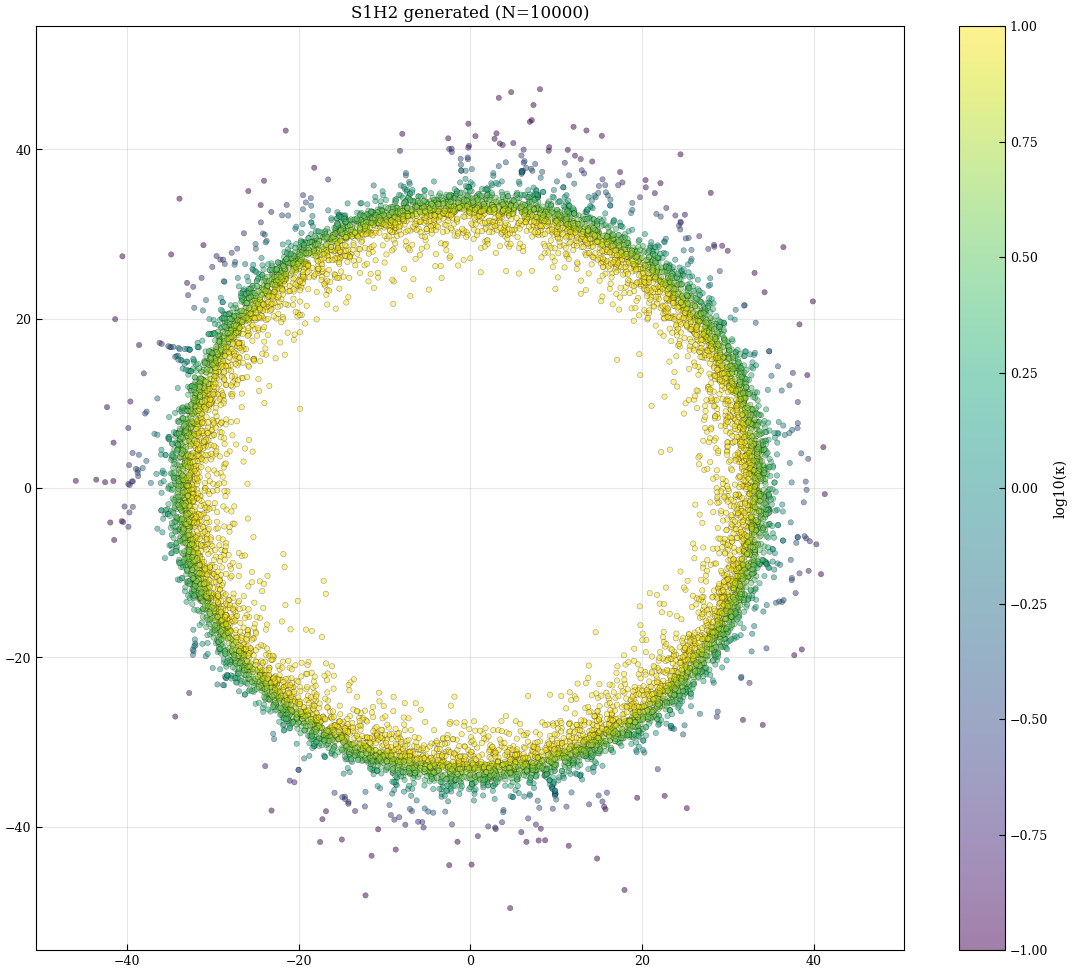

In [6]:
mercator_disc(df, title='S1H2 generated (N=10000)')

In [7]:
import numpy as np

def radius_to_poincare_robust(R, q=0.95, target_rho=0.85, clip_max=3.0):
    """
    R: radios originales [0, +inf)
    q: cuantil robusto usado como referencia (0.90-0.99)
    target_rho: dónde quieres que caiga ese cuantil en el disco (<1)
    clip_max: clip en unidades escaladas (evita saturación extrema)

    Mapeo:
      1) s = Q_q(R) / (2*atanh(target_rho))
      2) u = R/s
      3) rho = tanh( clip(u, 0, clip_max) / 2 )
    """
    R = np.asarray(R, dtype=float)
    R = np.where(np.isfinite(R) & (R >= 0), R, np.nan)

    Rq = np.nanquantile(R, q)
    s = Rq / (2.0 * np.arctanh(target_rho) + 1e-12)

    u = R / (s + 1e-12)
    u = np.clip(u, 0.0, clip_max)
    rho = np.tanh(u / 2.0)
    return rho, s

R = df["Disc.Radius"].to_numpy(float)
theta = df["Inf.Theta"].to_numpy(float)  # radianes

rho, scale_used = radius_to_poincare_robust(
    R, q=0.95, target_rho=0.85, clip_max=3.0
)

# z = rho * np.exp(1j * theta)

print("scale_used =", scale_used)

scale_used = 14.442779759690643


### Mapa

In [4]:
max(dict(G.degree()).items(), key=lambda x: x[1])

('996', 2496)

In [ ]:
mercator_disc(df, title='S1H2 generated (N=10000)', net=G)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0xff7ab4139730>>
Traceback (most recent call last):
  File "/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
/tmp/ipykernel_56612/3962882619.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


### Rotació 

In [8]:
mask = (df['Disc.Radius'] > 30) & (df['Disc.Radius'] < 35)
df[mask]

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y,Poincare.Radius,Poincare.X,Poincare.Y
0,0,4.04957,2.313680,33.9965,33.996507,-22.995734,25.039144,0.021715,-0.014688,0.015993
1,1,8.24794,0.915568,32.5738,32.573802,19.848530,25.828055,0.020806,0.012678,0.016497
3,3,2.97684,2.755460,34.6120,34.612004,-32.063607,13.035180,0.022108,-0.020480,0.008326
4,4,3.15751,4.612030,34.4942,34.494161,-3.455991,-34.320595,0.022032,-0.002207,-0.021922
5,5,8.66831,1.941120,32.4744,32.474381,-11.753036,30.272951,0.020742,-0.007507,0.019336
...,...,...,...,...,...,...,...,...,...,...
9831,9994,7.73722,2.925970,32.7016,32.701644,-31.944384,6.996703,0.020888,-0.020404,0.004469
9833,9996,8.05496,3.902130,32.6212,32.621152,-23.632907,-22.486114,0.020836,-0.015095,-0.014363
9834,9997,9.70515,2.846010,32.2484,32.248415,-30.849885,9.393876,0.020598,-0.019705,0.006000
9835,9998,7.85101,0.589653,32.6724,32.672444,27.155169,18.168253,0.020869,0.017345,0.011605


/tmp/ipykernel_139594/3474777642.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


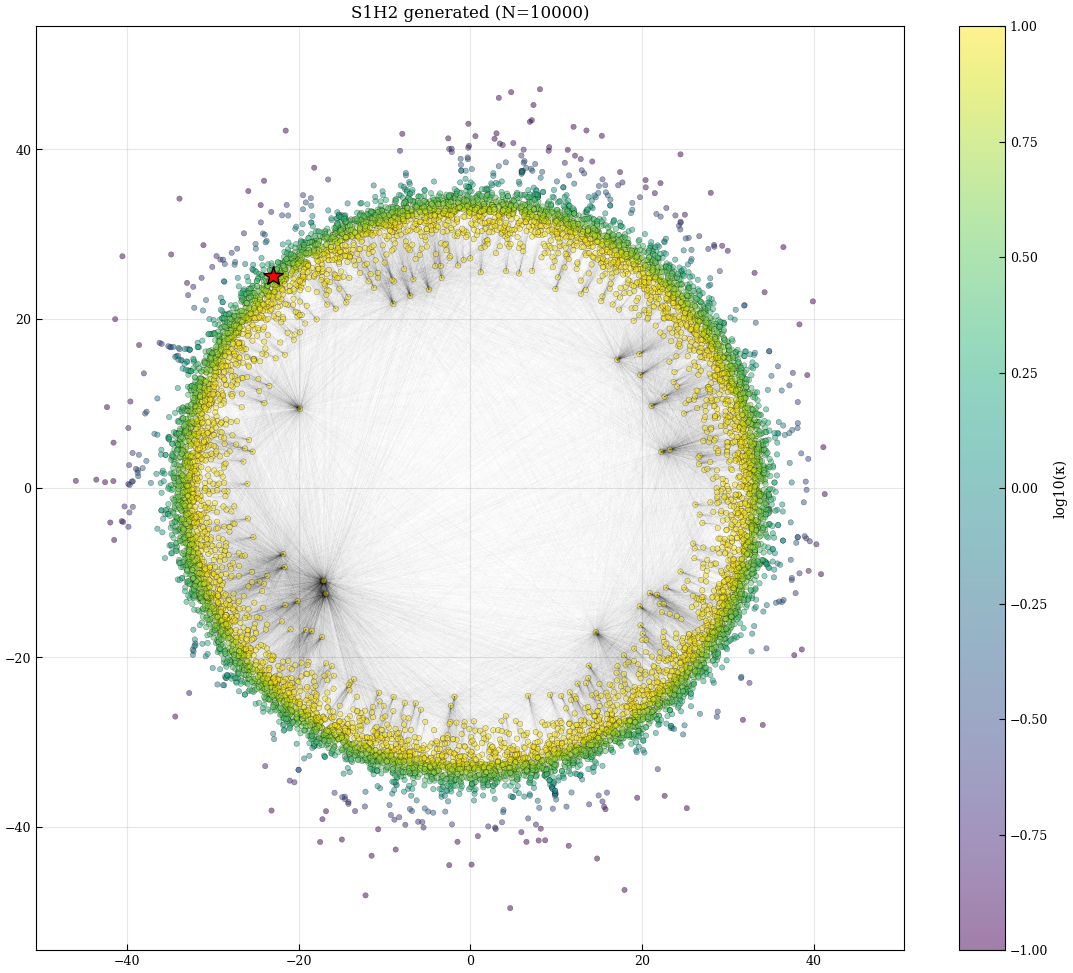

/tmp/ipykernel_139594/3474777642.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


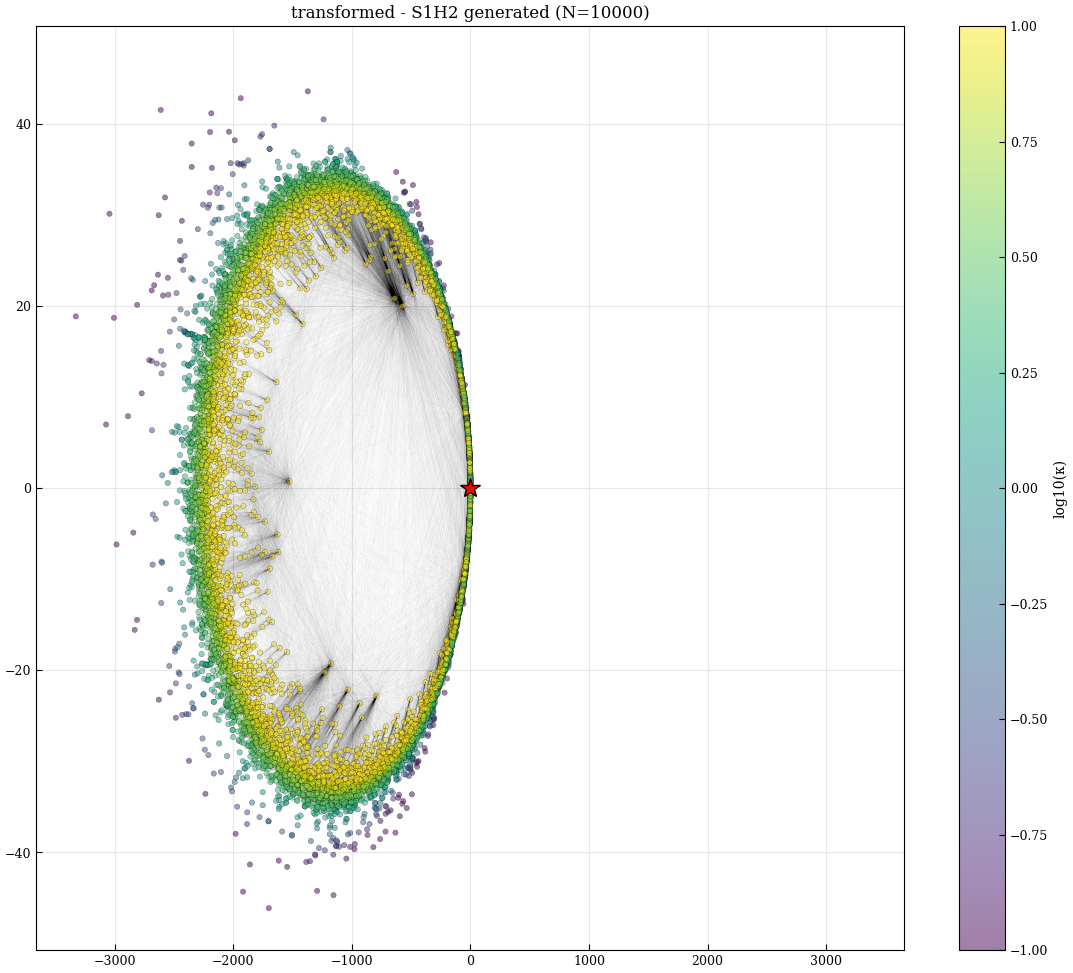

In [9]:
mercator_disc(df, title='S1H2 generated (N=10000)', mark_nodes=['0'], net=G)
df_new = hyperbolic_boost(df, '0')
mercator_disc(df_new, title='transformed - S1H2 generated (N=10000)', mark_nodes=['0'], net=G)


### Epidèmia

In [16]:
params

{'Elapsed CPU time': '2839.93 seconds',
 'Edgelist file': 'pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3_GC.edge',
 'nb. vertices': 9837.0,
 'beta': 3.0,
 'mu': 0.0342345,
 'radius_S1': 1565.61,
 'radius_H2': 50.7401,
 'kappa_min': 0.000936682,
 'EDGELIST_FILENAME': 'pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3_GC.edge',
 'ROOTNAME_OUTPUT': 'pipeline-output/out-n10000-g=2.2-b=3/n10000-g=2.2-b=3'}

#### Arxius

In [16]:
def epidemic_func_og(dist, R, c):
    return np.exp(-c*(dist-R))

def hyperbolic_distance_og(r_a, r_b, theta_diff, zeta=1.0):   
    cosh_val = np.cosh(zeta*r_a) * np.cosh(zeta*r_b) - \
               np.sinh(zeta*r_a) * np.sinh(zeta*r_b) * np.cos(theta_diff)
    cosh_val = np.clip(cosh_val, 1.0, None)
    return np.arccosh(cosh_val) / zeta

def link_probability_og(distance, R, c=1.0):
    """Probabilidad de enlace entre 0 y 1 (estable numéricamente)"""
    z = c * (distance - R)
    # Evitar overflow
    z = np.clip(z, -700, 700)  # exp(700) es ~10^304, cerca del límite
    return 1.0 / (1.0 + np.exp(z))

R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

hyperbolic_distance = np.vectorize(hyperbolic_distance_og, excluded={3, 'zeta'})
epidemic_func = np.vectorize(epidemic_func_og, excluded={1, 'R', 2, 'c'})
link_probability = np.vectorize(link_probability_og, excluded={1, 'R', 2, 'c'})

edges = pd.DataFrame(G.edges, columns=['a', 'b'])
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='a', right_on='Vertex', suffixes=('_a', '_b'))
edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='b', right_on='Vertex', suffixes=('_a', '_b'))
edges['Theta_Dif'] = np.pi - np.abs(np.pi - np.abs(edges['Inf.Theta_a']-edges['Inf.Theta_b']))

edges['Distance'] = np.where(edges['Theta_Dif'] == 0, 
                            np.abs(edges['Disc.Radius_a']- edges['Disc.Radius_b']), 
                            hyperbolic_distance(edges['Disc.Radius_a'], edges['Disc.Radius_b'], edges['Theta_Dif']))



for n in (-50, -5, 0, 5):
    n1 = n
    i = 2**n1
    c = params['beta']/i

    edges['Epidemic_Func'] = link_probability(edges['Distance'], R, c)

    avg_epidemic_func = np.average(edges['Epidemic_Func'])

    edges['Weight_Multiplier'] = edges['Epidemic_Func']/avg_epidemic_func
    edges.to_csv(f"{edges_file}_weight_2^{n1}", sep='\t', header=False, index=False, columns=['a', 'b', 'Weight_Multiplier'])

#### Estadístiques

In [7]:
output_batch_file = f"{working_folder}/batch_sir_evolution.txt"

infection_rates = reversed(range(1, 201))      # 1..200
random_seeds = range(1, 61)       # 1..60

recovery_rate = 1.0
limit_time = 20.0
model_type = 2   # SIR_MODEL
n = 0
with open(output_batch_file, "w") as f:
    f.write("# infection_rate  recovery_rate  seed  limit_time  model_type\n")
    for i in infection_rates:
        infection_rate = i * 2 / 100.0   # real(i_sim*2, dp)/100
        for j in random_seeds:
            seed = 42069 + j
            # Escribir línea con 5 valores (start_node opcional omitido)
            f.write(f"{infection_rate:.6f} {recovery_rate:.1f} {seed} {limit_time:.1f} {model_type}\n")
            n = n+1

print(f"Archivo batch generado: {output_batch_file} con {n} simulaciones.")

Archivo batch generado: ./pipeline-output/out-n10000-g=2.2-b=3/batch_sir_evolution.txt con 12000 simulaciones.


In [ ]:
n=5
folder = f'{working_folder}/weight_beta2^{n}'
weights = f'{edges_file}_weight_2^{n}'
origin = 0
! rm -rf {folder}
! mkdir {folder}
! ./tools/epidemics -b {output_batch_file} -o {folder} -st -w -sn {origin} {weights}

In [ ]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

for n in (-50, -5, 0):
    folder = f'{working_folder}/weight_beta2^{n}'
    weights = f'{edges_file }_weight_2^{n}'
    ! rm -rf {folder}
    ! mkdir {folder}
    ! ./tools/epidemics -b {output_batch_file} -o {folder} -st -w -sn {max_key} {weights}

In [ ]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

folder = f'{working_folder}/unweighted'
! rm -rf {folder}
! mkdir {folder}
! ./tools/epidemics -b {output_batch_file} -o {folder} -st -sn {max_key} {edges_file}

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool
import functools

LIMIT = 0.000

def process_rate(rate, weight=None):
    """Procesa todas las repeticiones para una tasa específica"""
    integrals = []
    outbreak_size = []
    
    for j in range(1, 61):
        filename = f"{working_folder}/{'unweighted' if weight is None else f'weight_beta2^{weight}'}/stats-n10000-g=2.2-b=3-{'' if weight == None else 'w'}SIR-I=   {rate:.5f}-R=   1.00000-S={42069+j}.dat"
        df = pd.read_csv(filename, sep=r'\s+', header=None, 
                        names=['t', 'idens', 'rdens', 'irate', 'rrate'], 
                        engine='python', comment='#')
        # df['sdens'] = 1 - df['rdens'] - df['idens']
        # if (df['idens'].max() > LIMIT):
        #     integrals.append(np.trapezoid(df['idens'], df['t']))
        # if (df['rdens'].iloc[-1] > LIMIT):
        outbreak_size.append(df['rdens'].iloc[-1])
    
    if (len(integrals) == 0):
        integrals = [0]
    if (len(outbreak_size) == 0):
        outbreak_size = [0]
    
    return {
        "rate": rate,
        "integral": np.mean(integrals),
        # "err_integral": np.std(integrals),
        "outbreak_size": np.mean(outbreak_size),
        "err_outbreak_size": np.mean(outbreak_size)
    }

if __name__ == "__main__":
    iters = range(2, 400+1, 2)
    dfs_weights = {}
    
    for weight in (-50, -5, 0, 5, None):
        rates = np.multiply(iters, 0.01)
        # Usar partial para fijar el argumento weight
        process_func = functools.partial(process_rate, weight=weight)
        
        with Pool() as pool:
            results = list(tqdm(pool.imap(process_func, rates), 
                            total=len(iters)))
        
        dfs_weights['unweighted' if weight is None else f'w_beta2^{weight}'] = pd.DataFrame(results)

100%|██████████| 200/200 [00:01<00:00, 146.59it/s]


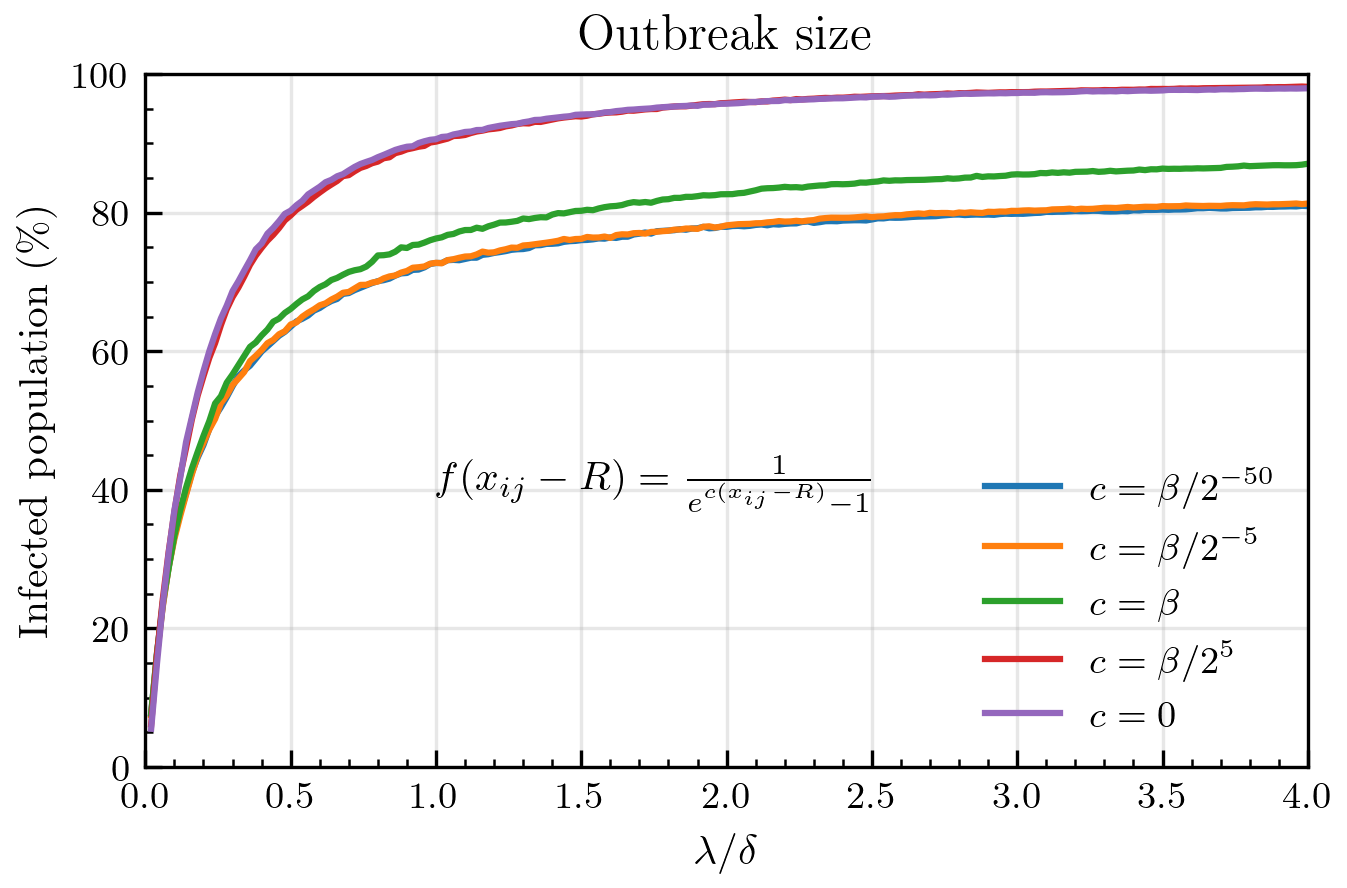

In [ ]:
# set_gnuplot_style()
fig, ax = plt.subplots(figsize=(5,3), dpi=300)
ax.minorticks_on()
for weight in (-50, -5, 0, 5, None):
    df = dfs_weights['unweighted' if weight is None else f'w_beta2^{weight}']
    ax.plot(df['rate'], 
               df['outbreak_size'],
               label=('$c=0$' if weight == None else r'$c=\beta$' if weight == 0 else f'$c=\\beta/2^{{{weight}}}$'))
# ax.errorbar(dfs['rate'], dfs['integral'], yerr=dfs['err_integral'], marker='o', linestyle='none')
# ax.scatter(df_data['x'], df_data['y'], marker='o')
ax.set_xlabel(r'$\lambda/\delta$')
ax.set_ylim(0, 1)
ax.set_yticks([i*0.2 for i in range(6)])
ax.set_yticklabels([str(i*20) for i in range(6)])
ax.set_xlim(0, 4)
# ax.legend("Outbreak")
# ax.set_ylim(0)
ax.set_ylabel(r'Infected population (\%)')
ax.annotate(r'$f(x_{ij}-R) = \frac{1}{e^{c(x_{ij}-R)}+1}$', (1, 0.4))
ax.legend()
ax.grid(alpha=0.3)
ax.set_title('Outbreak size')
fig.savefig('./figures/wSIR-outbreak-size.pdf')
plt.show()

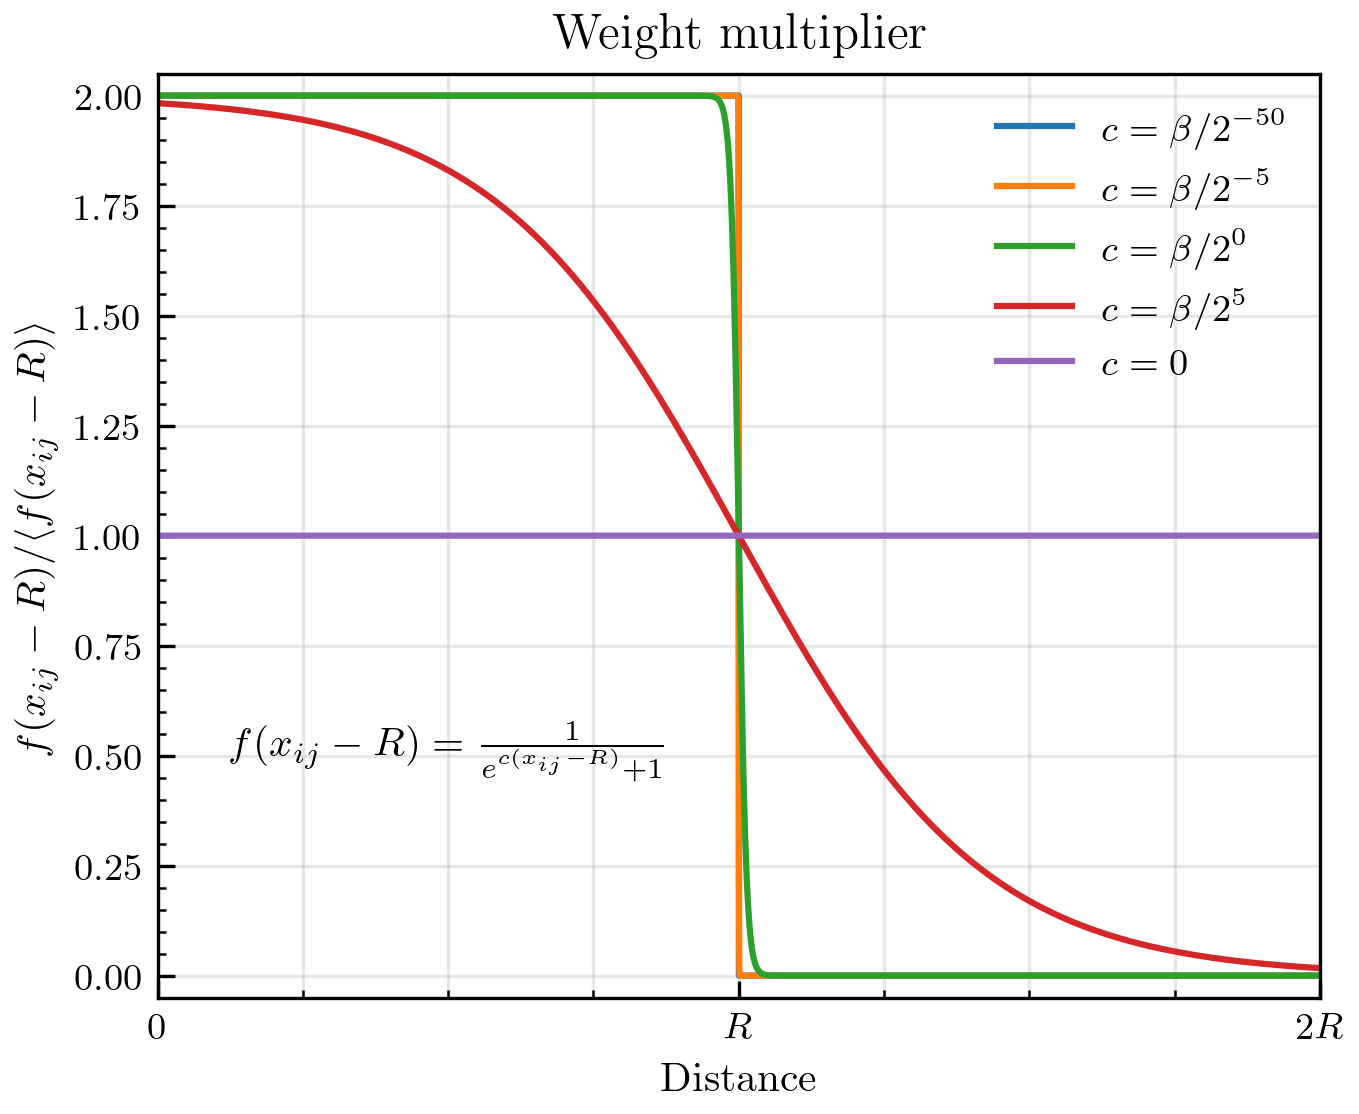

In [ ]:
fig, ax = plt.subplots(figsize=(5,4),dpi=300)
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

ax.xaxis.set_minor_locator(MultipleLocator(R/4))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xticks(ticks=[0, R, 2*R], 
              labels=['$0$', '$R$', '$2R$'])
xs = np.linspace(0, 2*R, 100000)

for n in (-50, -5, 0, 5):
    i = 2**n
    prob = link_probability(xs, R, params['beta']/i)
    avprob = np.average(prob)
    ax.plot(xs, prob/avprob, label=f'$c=\\beta/2^{{{n}}}$')

prob = link_probability(xs, R, 0)
avprob = np.average(prob)
ax.plot(xs, prob/avprob, label=f'$c=0$')

ax.set_xlabel('Distance')
ax.set_ylabel(r'$f(x_{ij}-R)/\langle f(x_{ij}-R) \rangle$')
ax.set_xlim(0, 2*R)
ax.set_ylim(-0.05, 2.05)
ax.annotate(r"$f(x_{ij}-R) = \frac{1}{e^{c(x_{ij}-R)}+1}$", (R/8, 0.5))
ax.legend()
ax.grid(alpha=0.3, which='minor', axis='x')
ax.grid(alpha=0.3, which='major')
ax.set_title('Weight multiplier')
fig.savefig('./figures/weight-multiplier.pdf')
plt.show()


#### GIF

In [ ]:
! ./tools/epidemics --help

In [18]:
from pathlib import Path
i_rate = 0.53
r_rate = 1
seed = 42070
model = 'SIR'
weighted = False
start_node = '0'
weight_file = f'{edges_file}_weight_2^5'
# weight_file = f'{edges_file}'
epidemic_folder = f'{working_folder}/epidemic_2^5'
expected_events_name = f'{epidemic_folder}/events-{Path(edges_file).stem}-{'w' if weighted else ''}{model}-I={i_rate:10.5f}-R={r_rate:10.5f}-S={seed:5d}.dat'
expected_stats_name = f'{epidemic_folder}/stats-{Path(edges_file).stem}-{'w' if weighted else ''}{model}-I={i_rate:10.5f}-R={r_rate:10.5f}-S={seed:5d}.dat'

In [ ]:
! rm -rf {epidemic_folder}
! mkdir {epidemic_folder}
! ./tools/epidemics -m {model} -i {i_rate} -r {r_rate} -lt 10000 -sn {start_node} -s {seed} -o {epidemic_folder} -st -ss 10 -ev {'-w' if weighted else ''} {weight_file}
print(expected_events_name)

In [19]:
events_file = expected_events_name
def skip_comments(line_index, line):
    # Saltar si la línea empieza con '#' o ' #'
    return line.strip().startswith('#') or line.lstrip().startswith('#')

with open(events_file, 'r') as f:
        lines = f.readlines()
    
    # Encontrar la primera línea de datos
first_data_line = 0
for step, line in enumerate(lines):
    if not line.lstrip().startswith('#'):
        first_data_line = step
        break
events = pd.read_csv(events_file, 
                        sep='\\s+', skiprows=first_data_line, names=['t', 'vertex', 'event'])
events['vertex'] = events['vertex'].astype(str)

events

,t,vertex,event
0,0.000000,0,I
1,0.328186,1033,I
2,0.372069,5846,I
3,0.379740,4882,I
4,0.383093,5290,I
...,...,...,...
16088,8.533224,7568,R
16089,8.998594,7756,R
16090,9.069759,1078,R
16091,9.122668,5704,R


In [ ]:
def load_sir(filename: str) -> pd.DataFrame:
    df = pd.read_csv(filename, sep=r'\s+', header=None, comment='#',
                    names=['t','idens', 'rdens', 'irate', 'rrate'], 
                    engine='python')
    df['sdens'] = 1 - df['rdens'] - df['idens']
    return df

from matplotlib import axes as mpl_ax



fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

def plot_graph(ax: mpl_ax.Axes, df: pd.DataFrame):
    ax.minorticks_on()
    ax.scatter(df['t'], df['sdens'], label='Susceptible', s=1)
    ax.scatter(df['t'], df['idens'], label='Infected', s=1)
    ax.scatter(df['t'], df['rdens'], label='Recovered', s=1)
    ax.set_xlabel('t (s)')
    ax.set_yticks([i*20/100 for i in range(6)])
    ax.set_yticklabels([str(i*20) for i in range(6)])
    ax.set_ylabel(r'\% population')
    ax.grid()
    # NO incluir leyenda aquí
df_SIR = load_sir(expected_stats_name)
plot_graph(ax, df_SIR)

# Crear handles personalizados para la leyenda
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', 
           markersize=8, label='Susceptible', markeredgecolor='tab:blue'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', 
           markersize=8, label='Infected', markeredgecolor='tab:orange'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', 
           markersize=8, label='Recovered', markeredgecolor='tab:green')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.07), ncol=3)
# plt.tight_layout(rect=[0, 0.05, 1, 1])  # Ajustar espacio para la leyenda
plt.show()


In [20]:
import math
import os
import shutil
import signal
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
from concurrent.futures import ThreadPoolExecutor

def mercator_disc_epidemic_anim(
    df,
    events,
    epidemics_fig_output,
    step=0.1,
    t_start=None,
    t_end=None,
):
    """
    Simula una epidemia en el disco hiperbólico y genera frames para un GIF/animación.

    Parámetros
    ----------
    df : DataFrame
        Datos de los nodos con columnas 'Vertex', 'Disc.X', 'Disc.Y'.
    events : DataFrame
        Eventos con columnas 't', 'vertex', 'event' (I o R).
    epidemics_fig_output : str
        Carpeta donde se guardarán las imágenes.
    step : float
        Incremento de tiempo entre frames.
    t_start : float, opcional
        Tiempo inicial de la animación. Si es None, se usa el min(events['t']).
    t_end : float, opcional
        Tiempo final de la animación. Si es None, se usa el max(events['t']).
    parallel : bool
        Si es True, renderiza las imágenes en paralelo. En Jupyter puede dar problemas,
        desactívalo si no puedes interrumpir el proceso.
    max_workers : int, opcional
        Número de procesos paralelos (solo si parallel=True). Por defecto usa los disponibles.
    """

    # ---------- Limpieza y preparación del directorio ----------
    if os.path.exists(epidemics_fig_output):
        shutil.rmtree(epidemics_fig_output)
    os.makedirs(epidemics_fig_output)

    # ---------- Coordenadas de los vértices ----------
    vertex_coords = df.set_index("Vertex")[["Disc.X", "Disc.Y"]].to_dict("index")

    # ---------- Conjuntos de estado (como coordenadas) ----------
    infected = set()
    recovered = set()
    susceptible = {(vertex_coords[v]["Disc.X"], vertex_coords[v]["Disc.Y"]) for v in df["Vertex"]}

    # ---------- Ventana temporal ----------
    if t_start is None:
        t_start = events["t"].min()
    if t_end is None:
        t_end = events["t"].max()

    print(f"Ventana temporal: {t_start:.2f} → {t_end:.2f}")

    # Número de pasos
    n_steps = math.ceil((t_end - t_start) / step)
    print(f"Total de frames: {n_steps}")

    # ---------- Eventos ordenados ----------
    events_sorted = events.sort_values("t").reset_index(drop=True)
    event_idx = 0
    n_events = len(events_sorted)

    # ---------- Fase 1: Simulación secuencial (rápida) ----------
    print("Simulando evolución de estados...")
    snapshots = []  # cada elemento: (t, list(susc), list(inf), list(rec))

    for i in tqdm(range(n_steps), desc="Simulación"):
        t = t_start + (i + 1) * step

        # Procesar eventos hasta t
        while event_idx < n_events and events_sorted.loc[event_idx, "t"] < t:
            ev = events_sorted.loc[event_idx]
            v = ev["vertex"]
            coords = (vertex_coords[v]["Disc.X"], vertex_coords[v]["Disc.Y"])

            if ev["event"] == "I":
                susceptible.discard(coords)
                recovered.discard(coords)
                infected.add(coords)
            elif ev["event"] == "R":
                infected.discard(coords)
                susceptible.discard(coords)
                recovered.add(coords)

            event_idx += 1

        # Guardar estado como listas (serializable)
        snapshots.append(
            (
                t,
                list(susceptible),
                list(infected),
                list(recovered),
            )
        )

    # ---------- Fase 2: Renderizado ----------

    for i, s in enumerate(tqdm(snapshots)):
        t, susc_list, inf_list, rec_list = s
    # La función mercator_epidemic_disc probablemente espera conjuntos
        mercator_epidemic_disc(
            df,
            set(susc_list),
            set(inf_list),
            set(rec_list),
            f"{epidemics_fig_output}/sim-{i:04d}.png",
            t,
        )


def generate_gif(df, epidemic_folder, events, boosted, start_node=None):
    df_new = df.copy()
    fig_output = f'{epidemic_folder}/disc'
    if boosted:
        fig_output += 'boosted'
        df_new = hyperbolic_boost(df, start_node)

    os.makedirs(fig_output, exist_ok=True)
    mercator_disc_epidemic_anim(
        df_new,
        events,
        fig_output,
        step=0.001,
        t_start=0.0,   # empezar en t=10
        t_end=2.0,     # terminar en t=20
    )

# ---------- Ejemplo de uso ----------
# generate_gif(df, epidemic_folder, events, False)
generate_gif(df, epidemic_folder, events, True, start_node)



Ventana temporal: 0.00 → 2.00
Total de frames: 2000
Simulando evolución de estados...


100%|██████████| 2000/2000 [08:36<00:00,  3.87it/s]


In [22]:
epidemics_fig_output = f'{epidemic_folder}/discboosted'
x1 = f"{epidemics_fig_output}/sim-%04d.png"
x2 = f"{epidemics_fig_output}/../discboosted.gif"
x3 = f"{epidemics_fig_output}/../discboosted-palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/aarch64-linux-gnu --incdir=/usr/include/aarch64-linux-gnu --arch=arm64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --e

## Paper con d = 1 - log (p)

In [17]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------------
# 1. Cargar datos
# ----------------------------
# Asumo que tienes:
# - G: grafo de networkx con N nodos (sin pesos)
# - df: DataFrame con columnas ['Vertex', 'Inf.Kappa', 'Inf.Theta', 'Disc.Radius']
# - R (float): radio efectivo R_hat del modelo S1/H2
# - beta (float): parámetro de clustering

# Ejemplo de carga (ajusta rutas y nombres de columna)
# df = pd.read_csv("coordenadas_mercator.csv")
# G = nx.read_edgelist("red_sintetica.edgelist", nodetype=int)

# Asegurar que los nodos de G y df coinciden
nodes = list(G.nodes())
N = len(nodes)
df = df.set_index('Vertex').loc[nodes].reset_index()
R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))

# Extraer arrays
theta = df['Inf.Theta'].values
r = df['Disc.Radius'].values
kappa = df['Inf.Kappa'].values

# ----------------------------
# 2. Función de distancia hiperbólica
# ----------------------------
def hyperbolic_distance(r_i, theta_i, r_j, theta_j):
    delta_theta = np.abs(theta_i - theta_j)
    delta_theta = np.minimum(delta_theta, 2*np.pi - delta_theta)
    # Aproximación usada en el modelo S1/H2
    x = r_i + r_j + 2 * np.log(delta_theta / 2 + 1e-12)
    return x

# ----------------------------
# 3. Calcular matriz de probabilidad P
# ----------------------------
# Usamos el sigmoide del modelo S1
def connection_prob(x, beta, R):
    return 1 / (1 + np.exp(0.5 * beta * (x - R)))

# Inicializar matriz P (dirigida: P[i,j] = prob de transición i <- j ?)
# Para distancia efectiva estándar, P[i,j] = fracción de flujo desde j hacia i.
# Normalizaremos por columnas (desde j hacia los demás)
P = np.zeros((N, N))

print("Calculando matriz de probabilidades...")
for i in tqdm(range(N)):
    for j in range(N):
        if i != j:
            x = hyperbolic_distance(r[i], theta[i], r[j], theta[j])
            p = connection_prob(x, params['beta'], R)

            P[i, j] = p


Calculando matriz de probabilidades...


100%|██████████| 9837/9837 [04:45<00:00, 34.50it/s]


In [19]:

# Normalizar por columnas (cada columna j suma 1)
col_sums = P.sum(axis=0)
P = P / col_sums

# ----------------------------
# 4. Distancia efectiva de un paso
# ----------------------------
# d_eff(i|j) = 1 - log(P[i,j])
with np.errstate(divide='ignore'):
    D1 = 1 - np.log(P)
D1[P == 0] = np.inf  # sin conexión directa

# ----------------------------
# 5. Calcular distancias efectivas acumuladas desde OL
# ----------------------------
# Elegir el nodo OL (por índice o por nombre)
# Cambia esto por el nodo que quieras como centro
OL = '0'  # o el nombre del nodo, e.g., OL = 'Node42'
if isinstance(OL, str):
    OL_idx = df[df['Vertex'] == OL].index[0]
else:
    OL_idx = OL


In [20]:

# Construir grafo dirigido con pesos = D1
G_eff = nx.DiGraph()
for i in range(N):
    for j in range(N):
        if i != j and np.isfinite(D1[i, j]):
            G_eff.add_edge(j, i, weight=D1[i, j])  # ojo: dirección j->i

# Distancia efectiva desde OL al resto
D_eff = nx.single_source_dijkstra_path_length(G_eff, source=OL_idx, weight='weight')

# Asegurar que todos los nodos tienen valor (inf si no alcanzable)
D_eff_array = np.full(N, np.inf)
for node, d in D_eff.items():
    D_eff_array[node] = d


: 

In [ ]:

# ----------------------------
# 6. Visualización radial centrada en OL
# ----------------------------
# Radio = distancia efectiva
# Ángulo = coordenada angular original (theta)
radii = D_eff_array
angles = theta.copy()

# El OL en el centro
radii[OL_idx] = 0.0

# Manejar nodos no alcanzables (ponerlos en el borde exterior)
inf_mask = np.isinf(radii)
if np.any(inf_mask):
    max_finite = np.max(radii[~inf_mask])
    radii[inf_mask] = max_finite * 1.2  # un poco más lejos

# Convertir a coordenadas cartesianas
x = radii * np.cos(angles)
y = radii * np.sin(angles)

# Dibujar
plt.figure(figsize=(10, 8))
pos = {node: (x[i], y[i]) for i, node in enumerate(nodes)}

# Colorear por distancia efectiva
node_colors = radii

# Dibujar aristas originales (opcional, puede ser denso)
# nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

# Dibujar nodos
sc = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap='viridis_r',
                             node_size=30, alpha=0.9)
plt.colorbar(sc, label='Distancia efectiva desde OL')

# Destacar OL
nx.draw_networkx_nodes(G, pos, nodelist=['0'], node_color='red',
                       node_size=100, edgecolors='black', linewidths=2)

# Etiquetas (opcional, puede saturar)
# nx.draw_networkx_labels(G, pos, font_size=8)

plt.title(f'Representación radial centrada en OL (nodo {OL})')
plt.axis('equal')
plt.tight_layout()
plt.show()

# ----------------------------
# 7. Validación opcional: correlación con tiempo de llegada simulado
# ----------------------------
# Si tienes tiempos de llegada T_a de una simulación SIR, puedes hacer:
# from scipy.stats import pearsonr
# corr, _ = pearsonr(T_a, D_eff_array)
# print(f"Correlación entre T_a y D_eff: {corr:.3f}")

print("Script completado.")